In [1]:
from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from matplotlib.pyplot import subplots , cm
import sklearn.model_selection as skm
from ISLP import load_data , confusion_table

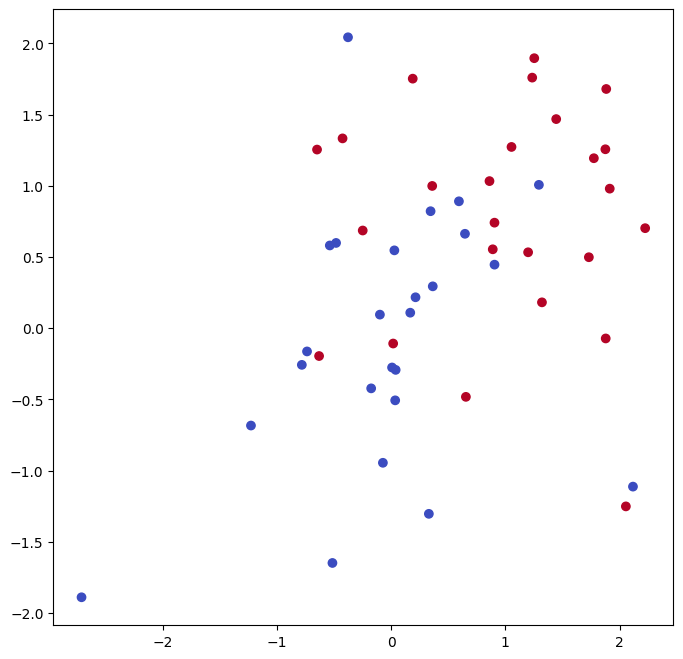

In [3]:
rng = np.random.default_rng(1)
X = rng.standard_normal((50, 2))
y = np.array([-1]*25+[1]*25)
X[y==1] += 1
fig , ax = subplots(figsize=(8,8))
ax.scatter(X[:,0],X[:,1],c=y,cmap=cm.coolwarm)

In [4]:
svm_linear = SVC(C=10, kernel='linear')
svm_linear.fit(X, y)

SVC(C=10, kernel='linear')

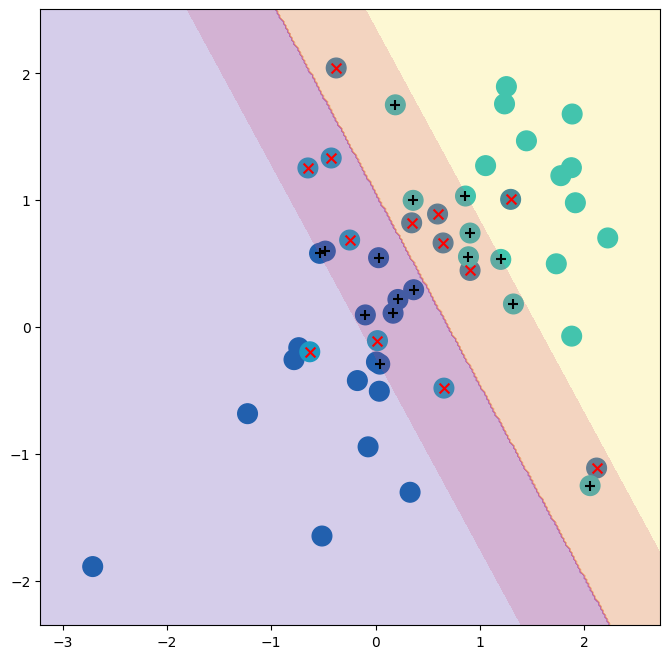

In [5]:
fig , ax = subplots(figsize=(8,8))
plot_svm(X,y,svm_linear,ax=ax)

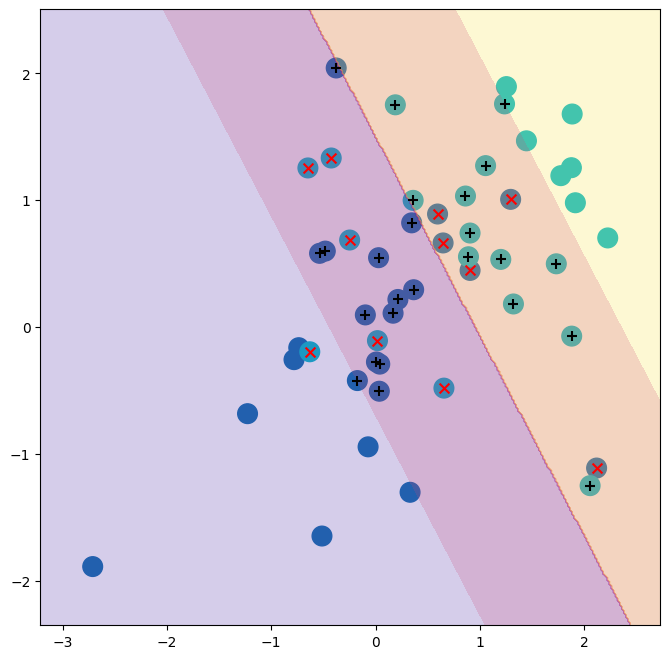

In [6]:
###different c value##
svm_linear_small = SVC(C=0.1, kernel='linear')
svm_linear_small.fit(X, y)
fig , ax = subplots(figsize=(8,8))
plot_svm(X,y,svm_linear_small,ax=ax)

In [7]:
###linear coefficient##
svm_linear.coef_

array([[1.17303943, 0.77348227]])

In [8]:
####cross-validation for the c###
kfold = skm.KFold(5,random_state=0,shuffle=True)
grid = skm.GridSearchCV(svm_linear,
{'C':[0.001,0.01,0.1,1,5,10,100]},
refit=True,
cv=kfold,
scoring='accuracy')

grid.fit(X, y)


GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=SVC(C=10, kernel='linear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]},
             scoring='accuracy')

In [9]:
grid.cv_results_[('mean_test_score')]

array([0.46, 0.46, 0.72, 0.74, 0.74, 0.74, 0.74])

In [10]:
####best parameter####
grid.best_params_

{'C': 1}

In [11]:
#####test data####
X_test = rng.standard_normal((20, 2))
y_test = np.array ([ -1]*10+[1]*10)
X_test[y_test==1] += 1

In [12]:
best_ = grid.best_estimator_
y_test_hat = best_.predict(X_test)
confusion_table(y_test_hat , y_test)

Truth,-1,1
Predicted,,
-1,8,4
1,2,6


In [13]:
###different c performances###
svm_ = SVC(C=0.001,kernel='linear').fit(X, y)
y_test_hat = svm_.predict(X_test)
confusion_table(y_test_hat , y_test)

Truth,-1,1
Predicted,,
-1,2,0
1,8,10


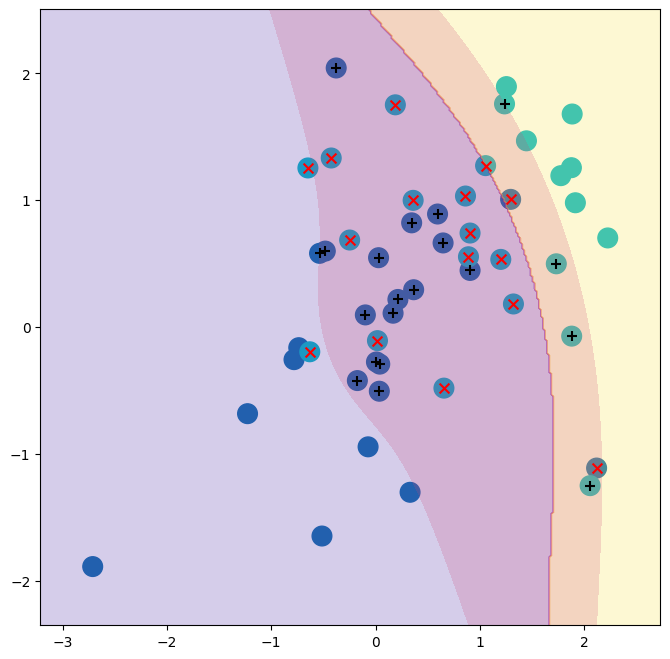

In [14]:
####polynomial kernel####
svm_poly = SVC(C=0.1, kernel='poly',degree=3)
svm_poly.fit(X, y)
fig, ax = subplots(figsize=(8,8))
plot_svm(X,y,svm_poly,ax=ax)

In [15]:
y_test_hat = svm_poly.predict(X_test)
confusion_table(y_test_hat , y_test)

Truth,-1,1
Predicted,,
-1,9,8
1,1,2


In [16]:
####cross-validation for parameters###
kfold = skm.KFold(5,random_state=0,shuffle=True)
grid = skm.GridSearchCV(svm_poly,
{'C':[0.001,0.01,0.1,1,5,10,100],
'degree':[1,2,3,4,5]},
refit=True,
cv=kfold,
scoring='accuracy')

grid.fit(X, y)
print(grid.cv_results_[('mean_test_score')])
print(grid.best_params_)

[0.46 0.46 0.42 0.44 0.44 0.46 0.46 0.52 0.54 0.64 0.74 0.58 0.64 0.54
 0.64 0.72 0.64 0.68 0.54 0.62 0.74 0.64 0.66 0.54 0.64 0.74 0.64 0.66
 0.54 0.64 0.74 0.64 0.7  0.54 0.64]
{'C': 0.1, 'degree': 1}


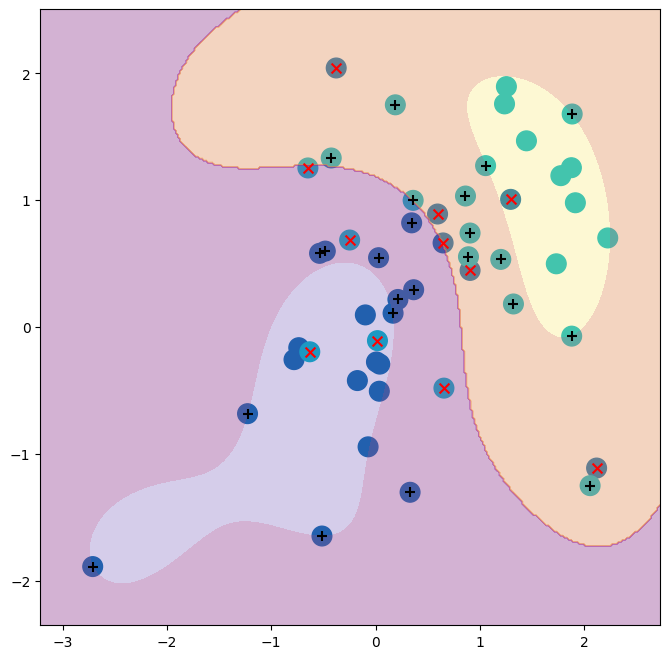

In [17]:
###radial kernel####
svm_rbf = SVC(kernel="rbf", gamma=.5, C=1)
svm_rbf.fit(X, y)
fig, ax = subplots(figsize=(8,8))
plot_svm(X,y,svm_rbf,ax=ax)

In [18]:
y_test_hat = svm_rbf.predict(X_test)
confusion_table(y_test_hat , y_test)

Truth,-1,1
Predicted,,
-1,8,3
1,2,7


In [19]:
####cross-validation for parameters###
kfold = skm.KFold(5,random_state=0,shuffle=True)
grid = skm.GridSearchCV(svm_rbf ,
{'C':[.00001,.0005,.001,.005,0.1,1,10,100,1000],
'gamma':[0.5,1,2,3,4]},
refit=True,
cv=kfold,
scoring='accuracy')

grid.fit(X, y)
print(grid.cv_results_[('mean_test_score')])
print(grid.best_params_)

[0.54 0.52 0.5  0.48 0.48 0.54 0.52 0.5  0.48 0.48 0.54 0.52 0.5  0.48
 0.48 0.54 0.52 0.5  0.48 0.48 0.54 0.52 0.5  0.48 0.48 0.74 0.7  0.7
 0.68 0.68 0.7  0.7  0.7  0.7  0.68 0.7  0.7  0.68 0.62 0.66 0.72 0.68
 0.62 0.64 0.66]
{'C': 1, 'gamma': 0.5}


In [20]:
best_svm = grid.best_estimator_
y_hat_test = best_svm.predict(X_test)
confusion_table(y_hat_test , y_test)

Truth,-1,1
Predicted,,
-1,8,3
1,2,7


In [21]:
# Load the Caravan dataset
caravan = load_data("Caravan")

# Prepare features and target
X_caravan = caravan.drop(columns='Purchase')
y_caravan = caravan['Purchase']

# Encode the target variable
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_caravan)  # Converts 'No' -> 0 and 'Yes' -> 1

# Train-Test split using train_test_split
X_train_caravan, X_test_caravan, y_train_caravan, y_test_caravan = train_test_split(
    X_caravan, y_encoded, test_size=0.5, random_state=8)

In [22]:
# Define the SVM model with RBF kernel as initial model for GridSearchCV
svm_model = SVC()

# Set up parameter grid to search over multiple kernels and other hyperparameters
param_grid = {
    'kernel': ['rbf', 'poly', 'sigmoid'],  # Kernel types
    'C': [0.001,1],  # Cost parameter
    'gamma': [0.5, 1],  # Kernel coefficient
    'degree': [1, 3]  # Degree of the polynomial kernel
}

In [23]:
# Set up cross-validation
kfold = skm.KFold(n_splits=5, random_state=0, shuffle=True)

# Define GridSearchCV
grid_search = skm.GridSearchCV(estimator=svm_model,
                           param_grid=param_grid,
                           refit=True,
                           cv=kfold,
                           scoring='accuracy')

# Fit GridSearchCV on the training data
grid_search.fit(X_train_caravan, y_train_caravan)

# Print cross-validation results and best parameters
print("Mean Test Scores for Each Parameter Combination:")
print(grid_search.cv_results_['mean_test_score'])
print("\nBest Parameters:", grid_search.best_params_)

Mean Test Scores for Each Parameter Combination:
[0.93851037 0.93851037 0.93851037 0.93851037 0.93851037 0.93851037
 0.93851037 0.87083459 0.93851037 0.93851037 0.86705629 0.93851037
 0.93438902 0.93851037 0.93851037 0.93473266 0.93816673 0.93851037
 0.93438902 0.86705629 0.93851037 0.93473266 0.86705629 0.93851037]

Best Parameters: {'C': 0.001, 'degree': 1, 'gamma': 0.5, 'kernel': 'rbf'}


In [24]:
best_svm = grid_search.best_estimator_

y_hat_test = best_svm.predict(X_test_caravan)
confusion_table(y_hat_test , y_test_caravan)

Truth,0,1
Predicted,,
0,2742,169
1,0,0
